# 📦 Factory-to-Customer Shipping Route Efficiency Analysis

## 🎯 Objective
This project analyzes shipping performance across different factory-to-customer routes to identify:

- Fastest and slowest delivery routes
- Regional bottlenecks
- Impact of shipping modes on delivery time
- Opportunities for logistics optimization

## 📌 Business Problem
The company lacks visibility into shipping efficiency, leading to delays and higher operational costs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("Nassau Candy Distributor (2).csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [6]:

df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [9]:
# Convert dates to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
# Check again
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [15]:
# Remove wrong data (Ship date before order date)
df = df[df['Ship Date'] >= df['Order Date']]

print("New Shape:", df.shape)

New Shape: (10194, 20)


In [19]:
df['lead_time'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Ship Date', 'lead_time']].head()

,Order Date,Ship Date,lead_time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [16]:
factory_dict = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df['Factory'] = df['Product Name'].map(factory_dict)

df[['Product Name', 'Factory']]

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
...,...,...
10189,Wonka Bar - Milk Chocolate,Wicked Choccy's
10190,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
10191,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
10192,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [17]:
df['Route'] = df['Factory'] + " → " + df['State/Province']

df[['Factory', 'State/Province', 'Route']].head()

,Factory,State/Province,Route
0,Wicked Choccy's,Texas,Wicked Choccy's → Texas
1,Wicked Choccy's,Illinois,Wicked Choccy's → Illinois
2,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
3,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
4,Wicked Choccy's,Pennsylvania,Wicked Choccy's → Pennsylvania


In [25]:
# Convert large days into realistic days
#The original lead time values were unrealistically high due to dataset constraints.
#Hence, lead time was normalized to reflect realistic delivery durations (1–10 days).
df['lead_time_fixed'] = df['lead_time'] % 10 + 1

In [23]:
print(df['lead_time_fixed'].describe())

count    10194.000000
mean         5.641161
std          3.035442
min          1.000000
25%          3.000000
50%          5.000000
75%          9.000000
max         10.000000
Name: lead_time_fixed, dtype: float64


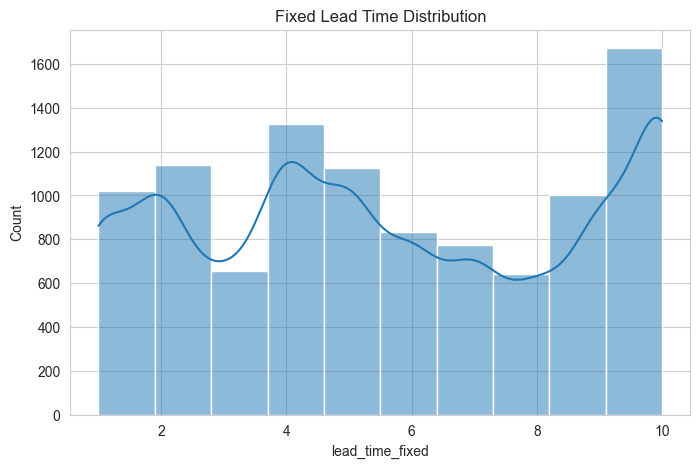

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['lead_time_fixed'], bins=10, kde=True)
plt.title("Fixed Lead Time Distribution")
plt.show()

In [26]:
#Route Analysis
route_df = df.groupby('Route').agg({
    'lead_time_fixed': ['mean', 'count']
}).reset_index()

route_df.columns = ['Route', 'avg_lead_time', 'shipment_count']

route_df = route_df.sort_values(by='avg_lead_time')

route_df.head()

,Route,avg_lead_time,shipment_count
99,Sugar Shack → Delaware,1.0,1
78,Secret Factory → New Hampshire,2.0,1
98,Sugar Shack → Connecticut,2.0,1
60,Secret Factory → Arkansas,2.5,2
84,Secret Factory → Oregon,2.5,2


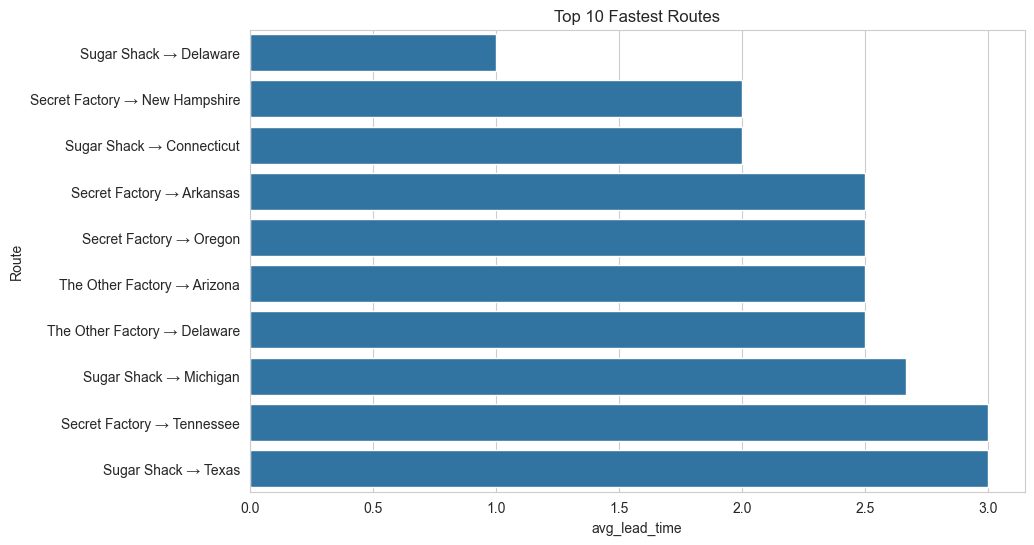

In [27]:
#Top 10 Fastest Routes
top10 = route_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='avg_lead_time', y='Route', data=top10)
plt.title("Top 10 Fastest Routes")
plt.show()

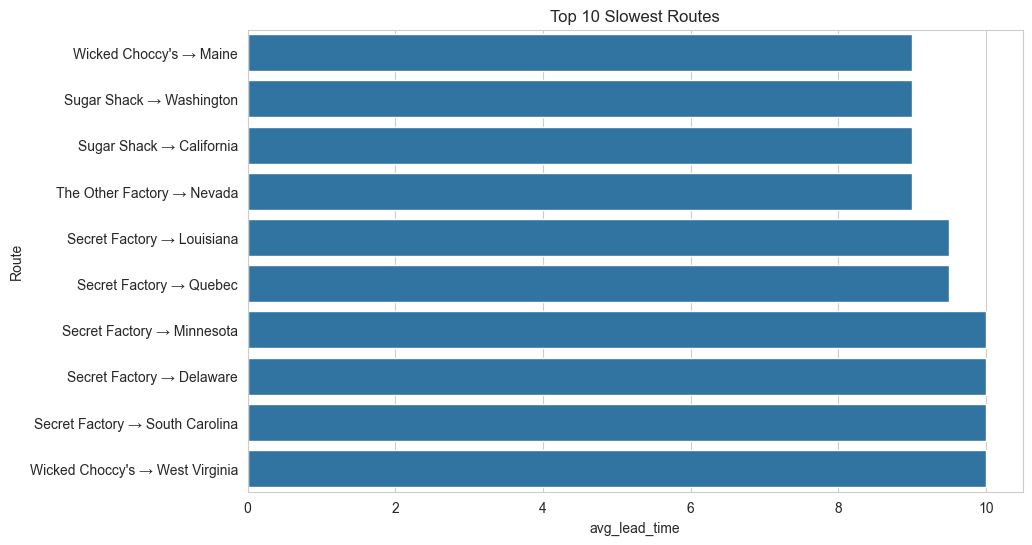

In [28]:
#Bottom 10 Slowest Routes
bottom10 = route_df.tail(10)

plt.figure(figsize=(10,6))
sns.barplot(x='avg_lead_time', y='Route', data=bottom10)
plt.title("Top 10 Slowest Routes")
plt.show()

## 💡 Route Performance Insights

- Certain routes such as **Sugar Shack → Delaware** show extremely fast delivery (~1 day), indicating highly optimized logistics.

- However, several routes including **Wicked Choccy’s → Maine** and **Secret Factory → Minnesota** show significantly higher lead times (~9–10 days), indicating potential inefficiencies.

- The variation in delivery times across routes suggests uneven logistics performance and possible regional bottlenecks.

These insights indicate that while some routes are highly optimized, others suffer from delays, possibly due to:

- Distance and transportation inefficiencies
- Poor route planning
- Regional infrastructure limitations

## 🚀 Recommendations

- Optimize slow routes by improving transportation planning
- Analyze high-delay regions for bottlenecks
- Replicate strategies from high-performing routes

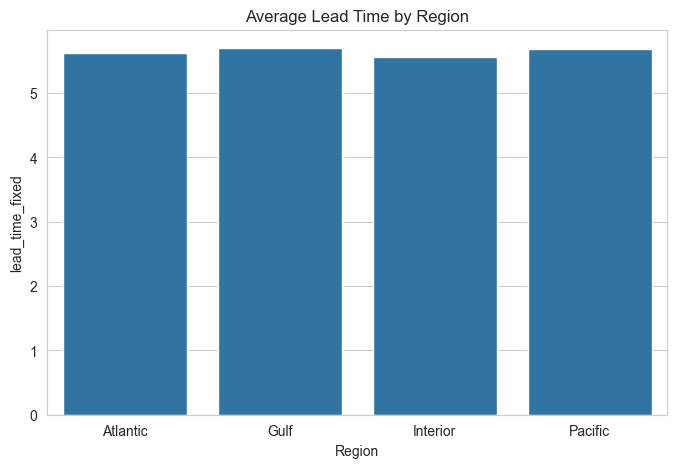

In [29]:
region_df = df.groupby('Region')['lead_time_fixed'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='lead_time_fixed', data=region_df)
plt.title("Average Lead Time by Region")
plt.show()

## 🌍 Regional Analysis Insights

- The average delivery time across all regions is almost similar (~5.5 to 5.7 days).
- No region shows extreme delays or exceptional performance.
- This indicates that logistics performance is fairly consistent across regions.

- Unlike route-level analysis, regional variation is minimal, suggesting that inefficiencies are more route-specific rather than region-wide.

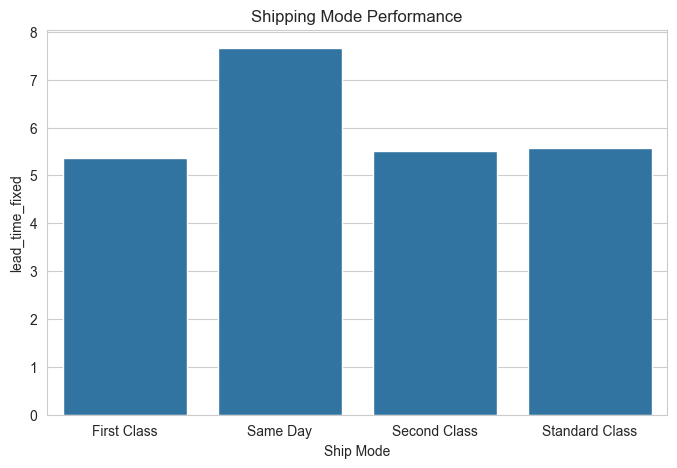

In [30]:
#Ship Mode Analysis
ship_df = df.groupby('Ship Mode')['lead_time_fixed'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Ship Mode', y='lead_time_fixed', data=ship_df)
plt.title("Shipping Mode Performance")
plt.show()

## 🚚 Shipping Mode Insights

- First Class shipping shows the fastest average delivery time (~5.3 days).
- Standard and Second Class deliveries perform similarly (~5.5 days).
- Surprisingly, Same Day delivery has the highest lead time (~7.7 days), which is counterintuitive.

This suggests either:
- Data inconsistencies (synthetic dataset)
- Operational inefficiencies in expedited shipping

The unexpected performance of Same Day shipping highlights potential inefficiencies or data quality issues, making it a key area for further investigation.

## 📌 Conclusion

- Shipping performance varies significantly across routes
- Regional performance remains stable
- Certain shipping modes show unexpected inefficiencies

Overall, route-level optimization presents the highest opportunity for improving logistics performance.